# AlexNet 2012
mạng sâu hơn LeNet và có nhiều kênh hơn

In [2]:
import torch
from torch import nn, optim

In [3]:
class AlexNet(nn.Module):
    def __init__(self, num_class):
        super(AlexNet, self).__init__()
        self.net = nn.Sequential(
            nn.LazyConv2d(out_channels=96, kernel_size=11, stride=4, padding=1), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3 ,stride=2),
            nn.LazyConv2d(out_channels=256, kernel_size=5, padding=2), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.LazyConv2d(out_channels=384, kernel_size=3, padding=1), nn.ReLU(),
            nn.LazyConv2d(out_channels=384, kernel_size=3, padding=1), nn.ReLU(),
            nn.LazyConv2d(out_channels=256, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Flatten(),
            nn.LazyLinear(out_features=4096), nn.ReLU(), nn.Dropout(p=0.5),
            nn.LazyLinear(out_features=4096), nn.ReLU(), nn.Dropout(p=0.5),
            nn.LazyLinear(out_features=num_class)
        )
    def layer_summary(self, X_shape):
        X = torch.randn(X_shape)
        for layer in self.net:
            X = layer(X)
            print(layer.__class__.__name__, 'output shape:\t', X.shape)
    
    def forward(self, X):
        return self.net(X)
        

In [4]:
model = AlexNet(1000)
model.layer_summary((1, 3, 224, 224))

Conv2d output shape:	 torch.Size([1, 96, 54, 54])
ReLU output shape:	 torch.Size([1, 96, 54, 54])
MaxPool2d output shape:	 torch.Size([1, 96, 26, 26])
Conv2d output shape:	 torch.Size([1, 256, 26, 26])
ReLU output shape:	 torch.Size([1, 256, 26, 26])
MaxPool2d output shape:	 torch.Size([1, 256, 12, 12])
Conv2d output shape:	 torch.Size([1, 384, 12, 12])
ReLU output shape:	 torch.Size([1, 384, 12, 12])
Conv2d output shape:	 torch.Size([1, 384, 12, 12])
ReLU output shape:	 torch.Size([1, 384, 12, 12])
Conv2d output shape:	 torch.Size([1, 256, 12, 12])
ReLU output shape:	 torch.Size([1, 256, 12, 12])
MaxPool2d output shape:	 torch.Size([1, 256, 5, 5])
Flatten output shape:	 torch.Size([1, 6400])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1,

In [11]:
import torchvision
from torchvision import transforms

trans = torchvision.transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor()])

data_train = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    transform=trans,
    download=True)
data_val = torchvision.datasets.FashionMNIST(
    root='./data',
    train=False,
    transform=trans,
    download=True
)

len(data_train), len(data_val)

(60000, 10000)

In [12]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    data_train,
    batch_size=128,
    shuffle=True
)

val_loader = DataLoader(
    data_val,
    batch_size=128,
    shuffle=False
)

In [13]:
!nvidia-smi

Wed Mar 18 07:36:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   71C    P0             29W /   70W |    1907MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [14]:
from torch import optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = AlexNet(10).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(params=model.parameters(), lr=0.01, weight_decay=0.01)

epochs = 10

loss_histoty = {"train": [], "val": []}

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        y_hat = model(X_batch)

        loss = criterion(y_hat, y_batch)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        train_loss += loss.item()
    train_loss_avg = train_loss / len(train_loader)
    loss_histoty["train"].append(train_loss_avg)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_hat = model(X_batch)
            loss = criterion(y_hat, y_batch)
            val_loss += loss.item()
        
        val_loss_avg = val_loss / len(val_loader)
        loss_histoty["val"].append(val_loss_avg)
    print(f"Epoch {epoch+1}/{epochs}: Train Loss: {train_loss_avg}, Val Loss: {val_loss_avg}")


Using device: cuda
Epoch 1/10: Train Loss: 2.3021991156311685, Val Loss: 2.3015979935851276
Epoch 2/10: Train Loss: 2.3010169387117885, Val Loss: 2.2997461904453327
Epoch 3/10: Train Loss: 2.2964589158609225, Val Loss: 2.284060508390016
Epoch 4/10: Train Loss: 1.4879491189395442, Val Loss: 1.0555251829231842
Epoch 5/10: Train Loss: 0.926067443290499, Val Loss: 0.8594677478452272
Epoch 6/10: Train Loss: 0.8186628228819954, Val Loss: 0.7608793521229225
Epoch 7/10: Train Loss: 0.7430537430716476, Val Loss: 0.7227709866777251
Epoch 8/10: Train Loss: 0.6745340773291679, Val Loss: 0.6434619106069396
Epoch 9/10: Train Loss: 0.6203598218686037, Val Loss: 0.6957701523847217
Epoch 10/10: Train Loss: 0.5817339772354565, Val Loss: 0.5531707985114448


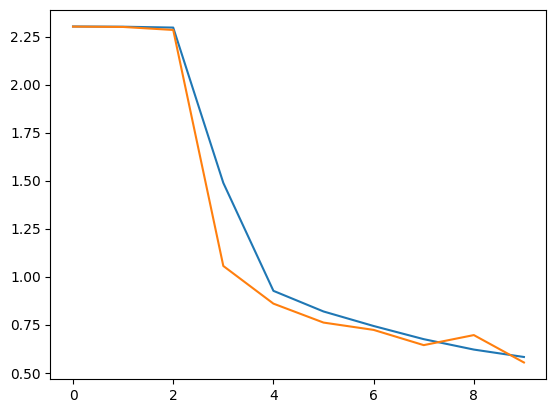

In [15]:
from matplotlib import pyplot as plt

plt.plot(loss_histoty["train"], label="train_loss")
plt.plot(loss_histoty["val"], label = "val_loss")

plt.show()

In [17]:
from sklearn.metrics import classification_report

# Tính toán predictions trên tất cả validation data
y_true = []
y_pred = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        y_hat = model.forward(X_batch)
        predictions = y_hat.argmax(dim=1)
        
        y_true.extend(y_batch.cpu().numpy())
        y_pred.extend(predictions.cpu().numpy())

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.78      0.76      1000
           1       0.95      0.93      0.94      1000
           2       0.60      0.68      0.64      1000
           3       0.77      0.84      0.80      1000
           4       0.56      0.78      0.65      1000
           5       0.96      0.87      0.91      1000
           6       0.60      0.20      0.30      1000
           7       0.86      0.94      0.90      1000
           8       0.93      0.95      0.94      1000
           9       0.93      0.94      0.94      1000

    accuracy                           0.79     10000
   macro avg       0.79      0.79      0.78     10000
weighted avg       0.79      0.79      0.78     10000

